# 鸢尾花分类入门 (Hello, ML!)

**目标**：用最少的代码完整体验一次监督学习的全流程。

**任务类型**：多分类（3 类鸢尾花：Setosa / Versicolor / Virginica）

**流程**：加载数据 → 划分训练/测试集 → 训练模型 → 评估 → 可视化

## 1. 导入依赖

In [51]:
# ===== 1. 导入第三方库 =====

# numpy: 数值计算基础库，提供高效的数组(ndarray)和矩阵运算
import numpy as np

# pandas: 数据分析库，提供 DataFrame 表格结构（类似 Excel）
import pandas as pd

# matplotlib.pyplot: Python 最常用的画图库，约定别名为 plt
import matplotlib.pyplot as plt

# load_iris: sklearn 自带的鸢尾花数据集加载函数（150 条样本，4 个特征，3 类）
from sklearn.datasets import load_iris

# train_test_split: 按比例把数据划分成训练集和测试集
from sklearn.model_selection import train_test_split

# StandardScaler: 特征标准化（让每个特征均值=0，方差=1）
from sklearn.preprocessing import StandardScaler

# LogisticRegression: 逻辑回归模型（虽然叫"回归"，但实际是分类算法）
from sklearn.linear_model import LogisticRegression

# 评估指标：
#   accuracy_score        - 计算准确率
#   classification_report - 输出 Precision/Recall/F1 详细报告
#   confusion_matrix      - 计算混淆矩阵
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# PCA: 主成分分析，常用降维算法（这里用来把 4 维数据降到 2 维方便画图）
from sklearn.decomposition import PCA

# 魔法命令：让 matplotlib 的图直接显示在 Notebook 里（不弹窗）
%matplotlib inline

# 固定 numpy 的随机种子为 42，保证每次运行结果一致（便于复现实验）
np.random.seed(42)

## 2. 加载数据并初步观察

- 4 个特征：花萼长度、花萼宽度、花瓣长度、花瓣宽度（单位 cm）
- 标签 y：0 / 1 / 2，对应三种鸢尾花

In [52]:
# ===== 2. 加载鸢尾花数据集 =====

# load_iris() 返回一个 Bunch 对象（类似字典），包含数据、标签、特征名等
data = load_iris()

# X 是特征矩阵：形状 (150, 4)，每行一朵花，每列一个特征
# y 是标签向量：形状 (150,)，每个值是 0/1/2，代表三种花
X, y = data.data, data.target

# 4 个特征的英文名：花萼长度、花萼宽度、花瓣长度、花瓣宽度
feature_names = data.feature_names

# 3 个类别的名字：['setosa', 'versicolor', 'virginica']
target_names = data.target_names

# 把 numpy 数组 X 转成 pandas 的 DataFrame，方便表格化查看
df = pd.DataFrame(X, columns=feature_names)

# 给 DataFrame 加一列 'species'，把数字标签 y 转成可读的英文名
# 列表推导式：对 y 中的每个数字 i，取对应的花名 target_names[i]
df['species'] = [target_names[i] for i in y]

# .head() 默认显示前 5 行，用来快速预览数据
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [53]:
# .describe() 输出每个数值列的统计摘要：
#   count - 样本数        mean - 均值         std - 标准差
#   min   - 最小值        25%  - 第一四分位数  50% - 中位数
#   75%   - 第三四分位数   max  - 最大值
# 用来快速了解数据的分布和量级
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [54]:
# .value_counts() 统计 'species' 列中每个值出现的次数
# 用来检查类别是否平衡（每类各 50 朵 = 完美平衡，无类别不均衡问题）
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 3. 数据可视化（PCA 降到 2 维）

可以看到三类花在二维空间已经基本分得开，是个很简单的任务。

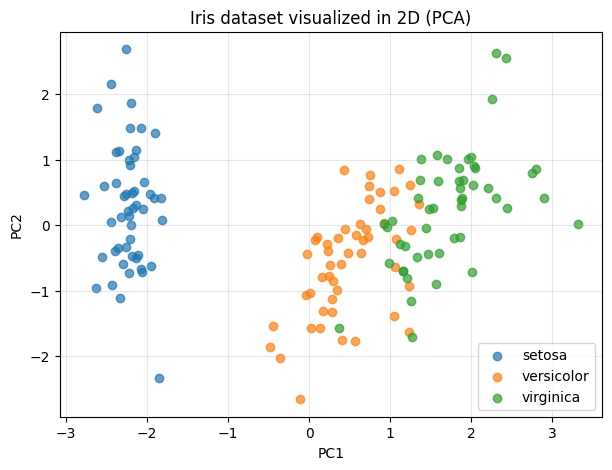

In [55]:
# ===== 3. PCA 降维并可视化 =====

# 链式调用，分两步：
# 第一步 StandardScaler().fit_transform(X)：先对 X 做标准化（每个特征均值 0、方差 1）
#         为什么要标准化？因为 PCA 基于方差，不同量纲的特征会让大数值特征"霸占"主成分
# 第二步 PCA(n_components=2).fit_transform(...)：把 4 维数据降到 2 维（保留方差最大的 2 个方向）
# 最终 X_2d 形状是 (150, 2)，可以直接画散点图
X_2d = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))

# 创建一张图，宽 7 英寸，高 5 英寸
plt.figure(figsize=(7, 5))

# enumerate 同时返回下标 i (0/1/2) 和元素 name (花名)
for i, name in enumerate(target_names):
    # y == i 是布尔数组，挑出当前类别的所有样本
    # X_2d[y == i, 0] 取这些样本的第 1 个主成分（横坐标）
    # X_2d[y == i, 1] 取第 2 个主成分（纵坐标）
    # alpha=0.7 设置透明度，避免点重叠看不清
    plt.scatter(X_2d[y == i, 0], X_2d[y == i, 1], label=name, alpha=0.7)

plt.xlabel('PC1'); plt.ylabel('PC2')                       # x、y 轴标签
plt.title('Iris dataset visualized in 2D (PCA)')           # 图标题
plt.legend(); plt.grid(alpha=0.3)                          # 显示图例和半透明网格
plt.show()                                                 # 显示图

## 4. 划分训练集 / 测试集

- `test_size=0.2`：20% 用作测试
- `stratify=y`：分层抽样，保证训练/测试集各类别比例一致
- `random_state=42`：固定随机种子，便于复现

In [56]:
# ===== 4. 划分训练集和测试集 =====

# train_test_split 一次返回 4 个对象（顺序固定）：
#   X_train - 训练集特征    X_test - 测试集特征
#   y_train - 训练集标签    y_test - 测试集标签
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                  # 输入：完整的特征和标签
    test_size=0.2,         # 测试集占 20%（即 30 条），训练集占 80%（120 条）
    random_state=42,       # 固定随机种子，保证每次划分结果一致（便于复现）
    stratify=y             # 分层抽样：保证训练/测试集中每类比例一致（这里各 10 朵）
)

# .shape 返回数组的维度元组，例如 (120, 4) 表示 120 行、4 列
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (120, 4) Test: (30, 4)


## 5. 特征标准化

逻辑回归对特征量纲敏感，先标准化（均值 0、方差 1）。

⚠️ **重要**：`fit` 只能在训练集上做，避免数据泄漏。

In [57]:
# ===== 5. 特征标准化（让不同量纲的特征可比） =====

# 创建一个标准化器对象
scaler = StandardScaler()

# 在【训练集】上 fit（计算均值和标准差），同时 transform（应用标准化）
# 公式：x_new = (x - mean) / std
X_train_std = scaler.fit_transform(X_train)

# 注意！这里只 transform 不 fit
# 用训练集学到的 mean/std 来变换测试集，避免"数据泄漏"（让模型偷看到测试集分布）
X_test_std = scaler.transform(X_test)

## 6. 训练模型：逻辑回归

In [58]:
# ===== 6. 训练逻辑回归模型 =====

# 创建模型对象
# max_iter=200：优化算法最多迭代 200 次（默认 100，鸢尾花数据需要更多迭代才能收敛）
model = LogisticRegression(max_iter=200)

# .fit(X, y)：用训练数据"喂给"模型，模型内部找到最优的权重参数
# 这是机器学习的核心一步："学习"就发生在这里
model.fit(X_train_std, y_train)

# .score(X, y)：返回模型在给定数据上的准确率（accuracy）
# 这里看训练集准确率，用来初步判断模型是否学到了东西
print('Training accuracy:', model.score(X_train_std, y_train))

Training accuracy: 0.9583333333333334


## 7. 在测试集上评估

In [59]:
# ===== 7. 在测试集上评估（这才是真实的模型能力） =====

# .predict(X)：让模型对每个样本输出一个预测的类别（0/1/2）
# y_pred 是形状 (30,) 的一维数组
y_pred = model.predict(X_test_std)

# accuracy_score(真实值, 预测值)：计算总体准确率 = 预测对的样本数 / 总样本数
print('Test accuracy:', accuracy_score(y_test, y_pred))
print()

# classification_report 输出更详细的分类指标：
#   precision (精确率) - 预测为该类的样本中，真正属于该类的比例
#   recall    (召回率) - 真正属于该类的样本中，被找出来的比例
#   f1-score          - 精确率和召回率的调和平均
#   support           - 该类样本总数
# target_names 让输出用花名而不是数字 0/1/2，更易读
print(classification_report(y_test, y_pred, target_names=target_names))

Test accuracy: 0.9333333333333333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 8. 混淆矩阵

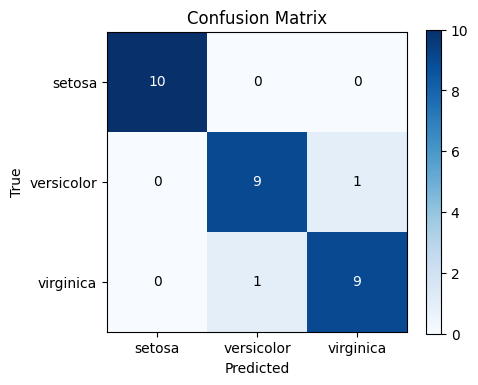

In [60]:
# ===== 8. 用混淆矩阵看模型把哪一类搞错了 =====

# 混淆矩阵 cm 是 3x3 矩阵：
#   行 = 真实类别，列 = 预测类别，对角线上的数字 = 预测正确的样本数
#   非对角线上的数字 = 错分的样本数（值越小越好）
cm = confusion_matrix(y_test, y_pred)

# 创建一张 5x4 英寸的图，ax 是这张图的坐标轴对象
fig, ax = plt.subplots(figsize=(5, 4))

# imshow 把矩阵当成"图片"画出来，cmap='Blues' 表示用蓝色渐变（值越大越深）
im = ax.imshow(cm, cmap='Blues')

# 设置 x、y 轴的刻度位置（0,1,2）和标签（花名）
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(target_names); ax.set_yticklabels(target_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')   # x 轴=预测，y 轴=真实
ax.set_title('Confusion Matrix')

# 双重循环：在每个格子中央写上对应的数字
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',                                # 水平/垂直居中
                color='white' if cm[i, j] > cm.max()/2 else 'black')    # 大数字白字，小数字黑字

plt.colorbar(im); plt.tight_layout(); plt.show()    # 加颜色条、自动布局、显示

## 9. 用模型做单点预测

假设新采样了一朵花：花萼 5.1×3.5，花瓣 1.4×0.2

In [61]:
# ===== 9. 用训练好的模型预测新样本 =====

# 构造一朵"新花"（实际上就是数据集里第一朵 setosa 的特征）
# 注意要写成二维数组 [[...]]，因为 sklearn 接受的是矩阵（多个样本），不是单个向量
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

# 用之前训练时的 scaler 做同样的标准化处理（关键：不能用新的 scaler）
new_flower_std = scaler.transform(new_flower)

# .predict() 返回预测的类别编号数组，[0] 取第一个（也是唯一一个）样本
pred = model.predict(new_flower_std)[0]

# .predict_proba() 返回属于每个类别的概率，形状 (1, 3)，[0] 取第一行
# 例如 [0.98, 0.02, 0.00] 表示 98% 概率是 setosa，2% 是 versicolor，0% 是 virginica
proba = model.predict_proba(new_flower_std)[0]

# f-string 格式化输出：把 pred(数字) 转成花名输出
print(f'预测类别: {target_names[pred]}')

# zip 把两个列表"拉链"式配对，同时遍历
# {p:.4f} 表示保留 4 位小数
for name, p in zip(target_names, proba):
    print(f'  P({name}) = {p:.4f}')

预测类别: setosa
  P(setosa) = 0.9808
  P(versicolor) = 0.0192
  P(virginica) = 0.0000


## 10. 小结

你刚刚完成了一次**完整的监督学习闭环**：

1. 加载并理解数据 ✅
2. 可视化探索（PCA 二维投影）✅
3. 训练/测试集划分（含分层抽样）✅
4. 特征标准化（避免数据泄漏）✅
5. 训练模型（逻辑回归）✅
6. 多种评估指标（准确率、Precision、Recall、F1、混淆矩阵）✅
7. 单样本预测（含概率）✅

### 下一步可以尝试
- 换成 `KNeighborsClassifier`、`DecisionTreeClassifier`、`RandomForestClassifier` 比较
- 用 `cross_val_score` 做 5 折交叉验证
- 用 `GridSearchCV` 调超参